# Pion production kernel — conservation tests

This notebook illustrates the physics behind `test_pion_kernel_absolute_normalization` and `test_species_kernels_and_helicity_chain` in `tests/test_consolidation.py`.

In photomeson production a nucleon (p or n) at Lorentz factor Γ interacts with a target photon:

$$N + \gamma \;\rightarrow\; N' + \pi, \qquad
  \gamma_\pi = \bar\kappa\,\Gamma\,\frac{m_p}{m_\pi}, \quad
  \gamma_p   = (1-\bar\kappa)\,\Gamma$$

Since $m_p/m_\pi \approx 6.7$ and $\bar\kappa \geq 0.2$, pions always appear **above** the parent boost bin while recoil protons appear **below**.

The high-level interface is `pion_production` and `proton_recoil_production`, available on any `InteractionCore` constructed with `photomeson='kernels'` — the same call pattern as `species_evolution_boost_range` and `light_cascade_production`.  The core is built from the self-contained PSB cross sections and a flat photon field, so no external data files are needed.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from crisp.core import InteractionCore
from crisp.photonuclear_cross_sections import PSB_model

# Flat photon field: normalization is irrelevant for the ratio-based conservation tests.
flat_field = lambda eps: np.ones_like(np.asarray(eps, dtype=float))

# Everything from arguments: PSB cross sections, the flat field, and the
# photomeson kernels (which enable pion_production / proton_recoil_production).
ic = InteractionCore(xsec_model=PSB_model(), target_photons=flat_field,
                     photomeson='kernels')
print(f"Boost grid: {ic.boosts[0]:.1e} – {ic.boosts[-1]:.1e}  ({len(ic.boosts)} points)")
print(f"pion_prod_tensor shape:    {ic.pion_prod_tensor.shape}")
print(f"proton_recoil_tensor shape: {ic.proton_recoil_tensor.shape}")

Boost grid: 1.0e+06 – 1.0e+14  (201 points)
pion_prod_tensor shape:    (2, 201, 201)
proton_recoil_tensor shape: (2, 201, 201)


## 1. Kernel matrices

Each row $i$ of `K[s, i, :]` is the secondary boost spectrum produced by a parent at bin $i$.
The off-diagonal structure reveals the kinematic direction: pion weight sits **above** the diagonal, recoil-proton weight **below**.

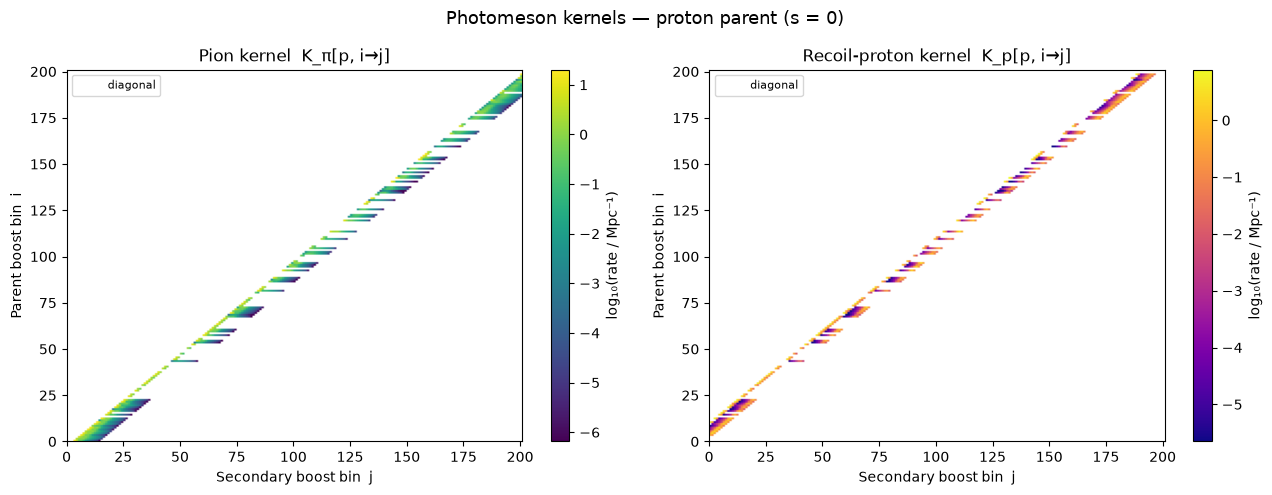

Boost-direction assertions passed (pions above, protons below parent bin).


In [2]:
K_pi = ic.pion_prod_tensor
K_pr = ic.proton_recoil_tensor

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

def log_image(ax, K, title, cmap):
    with np.errstate(divide='ignore'):
        img = np.log10(np.where(K > 0, K, np.nan))
    vmin = np.nanpercentile(img, 2)
    im = ax.imshow(img, origin='lower', aspect='auto', cmap=cmap,
                   vmin=vmin, vmax=np.nanmax(img),
                   extent=[0, K.shape[1], 0, K.shape[0]])
    ax.plot([0, K.shape[1]], [0, K.shape[0]], 'w--', lw=0.8, label='diagonal')
    ax.set_xlabel('Secondary boost bin  j')
    ax.set_ylabel('Parent boost bin  i')
    ax.set_title(title)
    plt.colorbar(im, ax=ax, label='log₁₀(rate / Mpc⁻¹)')
    ax.legend(fontsize=8)

log_image(axes[0], K_pi[0], 'Pion kernel  K_π[p, i→j]',          'viridis')
log_image(axes[1], K_pr[0], 'Recoil-proton kernel  K_p[p, i→j]', 'plasma')

plt.suptitle('Photomeson kernels — proton parent (s = 0)', fontsize=13)
plt.tight_layout()
plt.show()

# Boost direction check: pions only ever appear above the parent bin,
# recoil protons only below (the head-on mapping in the markdown above)
for i in [80, 100, 120]:
    assert np.all(K_pi[0, i, :i+1] == 0), f"Pion has weight at j ≤ {i}"
    assert np.all(K_pr[0, i, i:]   == 0), f"Proton has weight at j ≥ {i}"
print("Boost-direction assertions passed (pions above, protons below parent bin).")

## 2. Setup: Fe-56 injection and production over a range of boosts and distances

`pion_production` and `proton_recoil_production` accept the same arguments as `species_evolution_boost_range`: an injection vector, species index lists, a boost range, and an array of distances.  They return cumulative spectra spanning all requested boosts and distances in a single call.

In [3]:
alpha, mr, tr, _ = ic.get_distribution_parameters(
    mass_lims=(56, 0),
    injection_type=('only species', (26, 56)),
    absorption_type=('only mass', [1]),
)

# Parent boost range (11 boosts bracketing Γ ≈ 10^10)
boost_range = ic.boosts[95:106]

# Propagation distances
L_vals = np.concatenate([np.linspace(0, 10, 40), np.linspace(10, 500, 60)[1:]])

# Pion production: shape (n_b_full, n_L)
# n_b_full = len(ic.boosts) — secondary pion bins span the FULL boost grid
N_pion   = ic.pion_production(L_vals, alpha, mr, boost_range, tr)

# Recoil-proton production (default branching = 2/3): shape (n_b_full, n_L)
N_proton = ic.proton_recoil_production(L_vals, alpha, mr, boost_range, tr)

print(f"N_pion shape:   {N_pion.shape}   (n_b_pion, n_L)")
print(f"N_proton shape: {N_proton.shape}  (n_b_proton, n_L)")

N_pion shape:   (201, 99)   (n_b_pion, n_L)
N_proton shape: (201, 99)  (n_b_proton, n_L)


## 3. Cumulative pion and recoil-proton spectra vs distance

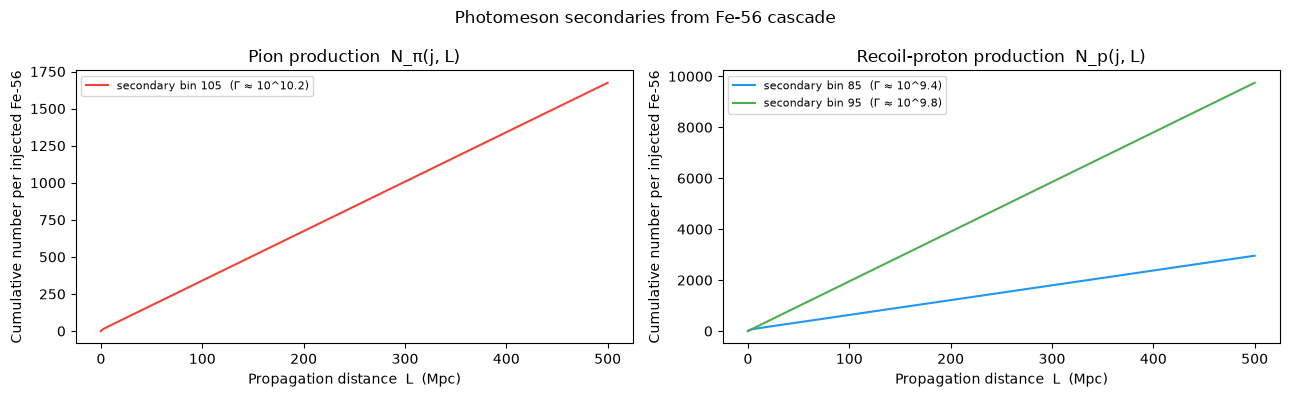

In [4]:
log_b = np.log10(ic.boosts)

# Select a few secondary boost bins to plot
secondary_bins = [85, 95, 105]  # bins below parent range (for protons) and above (for pions)
colors = ['#2196F3', '#4CAF50', '#F44336']

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)

for j, col in zip(secondary_bins, colors):
    label = f'secondary bin {j}  (Γ ≈ 10^{log_b[j]:.1f})'
    if N_pion[j].max() > 0:
        axes[0].plot(L_vals, N_pion[j],   color=col, label=label)
    if N_proton[j].max() > 0:
        axes[1].plot(L_vals, N_proton[j], color=col, label=label)

for ax, title in zip(axes, ['Pion production  N_π(j, L)', 'Recoil-proton production  N_p(j, L)']):
    ax.set_xlabel('Propagation distance  L  (Mpc)')
    ax.set_ylabel('Cumulative number per injected Fe-56')
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.suptitle('Photomeson secondaries from Fe-56 cascade', fontsize=12)
plt.tight_layout()
plt.show()

## 4. Nucleon conservation and the pion multiplicity

`build_photomeson_species_kernels` sums three interaction types (Δ-resonance, direct t-channel, multi-pion "charge democracy"), each normalized to the exact isotropic-field rate of its own cross-section component (`exact_rates_for_sigma`). One consequence is an *exact* identity: **every** photomeson interaction removes exactly one parent nucleon, so `proton_recoil_tensor`'s row sums equal the exact interaction rate identically — there is no free branching parameter to set.

The pion count is different. Resonance and direct-channel events produce one pion each, but multi-pion events produce three (one of each charge), so the row sums of `pion_prod_tensor` equal the interaction rate times a **multiplicity that varies with Γ** — rising wherever the multi-pion channel contributes a larger share of the total cross section, and never exceeding 3 (the multi-pion channel's own hard ceiling). This is verified directly by `test_pion_kernel_absolute_normalization` in `tests/test_consolidation.py`, which we reproduce here on the CMB.

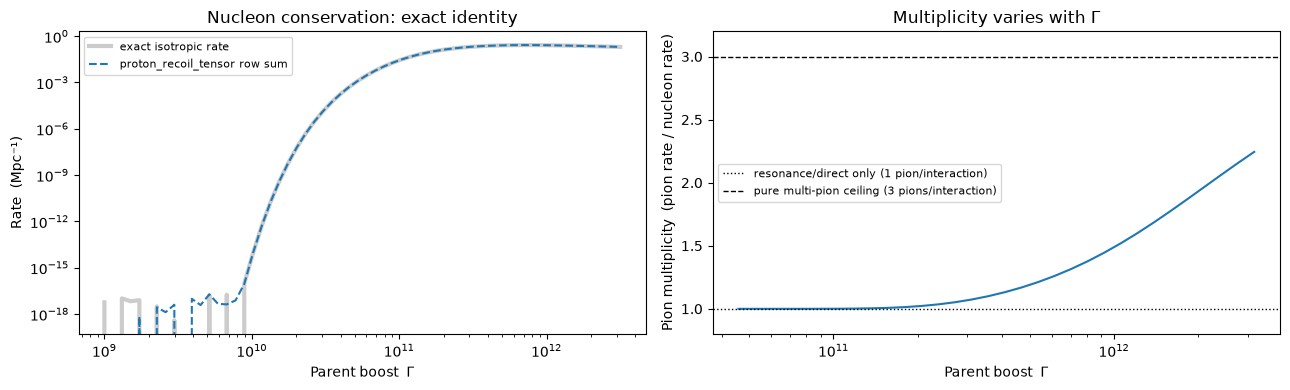

Nucleon identity: max relative deviation from the exact rate = 1.05e-15
Pion multiplicity range on this grid: 1.000 – 2.244


In [5]:
from crisp.core import build_pion_prod_kernel, build_proton_recoil_kernel
from crisp.interaction_rates import exact_rates_for_sigma
from crisp.photonuclear_cross_sections import pgamma_components
from crisp.background_photon_models import cmb_photon_density_GeVcm3

# GZK-relevant boost range on the CMB (same construction as
# test_pion_kernel_absolute_normalization)
boosts_gzk = np.logspace(9, 12.5, 60)
e_grid = np.logspace(np.log10(0.145), 4.0, 500)
comps = pgamma_components(e_grid)
sig_tot = 1e27 * sum(np.clip(c, 0, None) for c in comps.values())
r_exact = exact_rates_for_sigma(boosts_gzk, cmb_photon_density_GeVcm3, e_grid, sig_tot)[0]

K_N  = build_proton_recoil_kernel(boosts_gzk, cmb_photon_density_GeVcm3)
K_pi = build_pion_prod_kernel(boosts_gzk, cmb_photon_density_GeVcm3)
row_N  = K_N[0].sum(axis=1)
row_pi = K_pi[0].sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].loglog(boosts_gzk, r_exact, lw=3, color='0.8', label='exact isotropic rate')
axes[0].loglog(boosts_gzk, row_N, '--', color='C0', label='proton_recoil_tensor row sum')
axes[0].set_xlabel('Parent boost  Γ')
axes[0].set_ylabel('Rate  (Mpc⁻¹)')
axes[0].set_title('Nucleon conservation: exact identity')
axes[0].legend(fontsize=8)

# exclude the FFT/interpolation noise floor near threshold, where both
# row_N and row_pi sit ~14 orders of magnitude below their peak and any
# ratio of the two is numerical noise, not physics (see the analogous
# significance cut in test_pion_kernel_absolute_normalization)
sig = row_N > 1e-3 * row_N.max()
mult = row_pi[sig] / row_N[sig]
axes[1].semilogx(boosts_gzk[sig], mult)
axes[1].axhline(1.0, color='k', ls=':', lw=1, label='resonance/direct only (1 pion/interaction)')
axes[1].axhline(3.0, color='k', ls='--', lw=1, label='pure multi-pion ceiling (3 pions/interaction)')
axes[1].set_xlabel('Parent boost  Γ')
axes[1].set_ylabel('Pion multiplicity  (pion rate / nucleon rate)')
axes[1].set_title('Multiplicity varies with Γ')
axes[1].set_ylim(0.8, 3.2)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

d_identity = np.abs(row_N[row_N > 0] - r_exact[row_N > 0]).max() / r_exact.max()
print(f"Nucleon identity: max relative deviation from the exact rate = {d_identity:.2e}")
print(f"Pion multiplicity range on this grid: {mult.min():.3f} – {mult.max():.3f}")

## 5. Why the multiplicity rises with Γ

The head-on mapping places the effective target-frame photon energy at ε′ = 2Γε: for a fixed CMB photon energy ε, increasing Γ pushes ε′ further along the cross section — from the Δ(1232) resonance region into the multi-pion continuum, where `pgamma_components` shows multi-pion production overtaking the resonance at high photon energy (`test_pgamma_components_decomposition`). The multiplicity therefore climbs from 1 (pure resonance/direct) toward 3 (pure multi-pion) as Γ increases, then turns over once Γ is high enough that ε′ probes the exponentially suppressed tail of the CMB's own photon spectrum, where the interaction rate — and the interaction-type mix behind it — is dominated by whichever photons remain.

In [6]:
# Cross-check against the tolerances test_pion_kernel_absolute_normalization actually pins
assert d_identity < 1e-10, "nucleon conservation should hold to numerical precision"
assert 1.0 <= mult.min() and mult.max() < 3.01, "multiplicity must stay within [1, 3)"

i_peak = np.argmax(mult)
print(f"Multiplicity peaks at {mult[i_peak]:.3f} around Γ ≈ {boosts_gzk[sig][i_peak]:.2e}")
print("Both bounds match the tolerances asserted in "
      "tests/test_consolidation.py::test_pion_kernel_absolute_normalization.")

Multiplicity peaks at 2.244 around Γ ≈ 3.16e+12
Both bounds match the tolerances asserted in tests/test_consolidation.py::test_pion_kernel_absolute_normalization.
